In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize
import os
import warnings
warnings.filterwarnings('ignore')

# Selected from DAX 40 fundamental screening – 8 companies, 8 sectors
tickers = {
    'RHM.DE': 'Rheinmetall',
    'ENR.DE': 'Siemens Energy',
    'SAP.DE': 'SAP',
    'AIR.DE': 'Airbus',
    'SIE.DE': 'Siemens',
    'DTE.DE': 'Deutsche Telekom',
    'MUV2.DE': 'Munich Re',
    'ADS.DE': 'Adidas'
}

os.makedirs('data', exist_ok=True)
print("Libraries loaded")

Libraries loaded


In [6]:
# 3 years of daily data – captures full market cycle
# 2022 rate shock + 2023 recovery + 2024 bull run
raw = yf.download(
    list(tickers.keys()),
    start='2022-01-01',
    end='2026-03-01',
    progress=False
)['Close']

raw.columns = [tickers[t] for t in raw.columns]
raw = raw.dropna(thresh=len(tickers) - 2).ffill()

# Log returns – statistically more appropriate for portfolio optimization
returns = np.log(raw / raw.shift(1)).dropna()

print(f"Loaded {raw.shape[0]} trading days")
print(f"Range: {raw.index[0].date()} → {raw.index[-1].date()}")

Loaded 1060 trading days
Range: 2022-01-03 → 2026-02-27


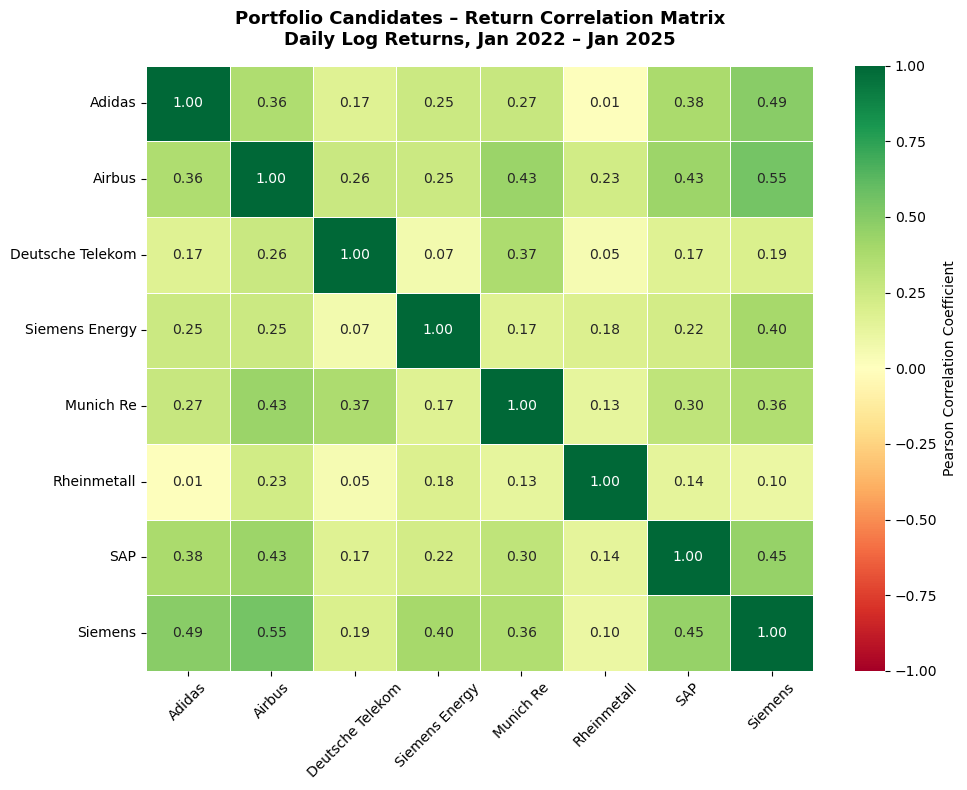

Saved to data/02_correlation_heatmap.png


In [7]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
ax.set_title(
    'Portfolio Candidates – Return Correlation Matrix\n'
    'Daily Log Returns, Jan 2022 – Jan 2025',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('data/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/02_correlation_heatmap.png")

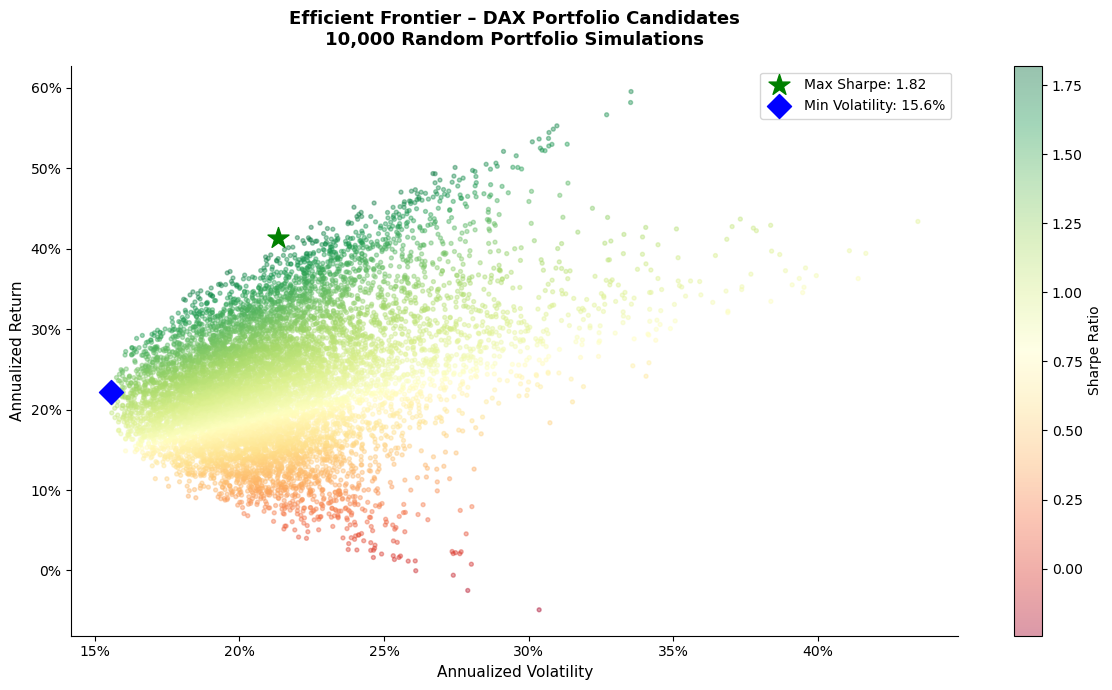

Saved to data/02_efficient_frontier.png


In [8]:
rf           = 0.025
cov_matrix   = returns.cov() * 252
mean_returns = returns.mean() * 252
n            = len(tickers)

np.random.seed(42)
n_portfolios = 10_000

port_returns, port_vols, port_sharpes = [], [], []

for _ in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n))
    r = np.dot(w, mean_returns)
    v = np.sqrt(w @ cov_matrix @ w)
    port_returns.append(r)
    port_vols.append(v)
    port_sharpes.append((r - rf) / v)

port_returns = np.array(port_returns)
port_vols    = np.array(port_vols)
port_sharpes = np.array(port_sharpes)

max_sharpe_idx = port_sharpes.argmax()
min_vol_idx    = port_vols.argmin()

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    port_vols, port_returns,
    c=port_sharpes, cmap='RdYlGn',
    alpha=0.4, s=8
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

ax.scatter(
    port_vols[max_sharpe_idx], port_returns[max_sharpe_idx],
    color='green', s=250, zorder=5, marker='*',
    label=f"Max Sharpe: {port_sharpes[max_sharpe_idx]:.2f}"
)
ax.scatter(
    port_vols[min_vol_idx], port_returns[min_vol_idx],
    color='blue', s=150, zorder=5, marker='D',
    label=f"Min Volatility: {port_vols[min_vol_idx]:.1%}"
)

ax.set_title(
    'Efficient Frontier – DAX Portfolio Candidates\n'
    '10,000 Random Portfolio Simulations',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Annualized Volatility', fontsize=11)
ax.set_ylabel('Annualized Return', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('data/02_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/02_efficient_frontier.png")

In [11]:
# Risk Parity: each stock contributes equally to total portfolio risk
# More robust than Max Sharpe which over-concentrates in recent outperformers
# Approach used by Bridgewater and major quant asset managers

def risk_parity_objective(weights, cov_matrix):
    port_vol         = np.sqrt(weights @ cov_matrix @ weights)
    marginal_contrib = cov_matrix @ weights
    risk_contrib     = weights * marginal_contrib / port_vol
    target           = port_vol / n
    return np.sum((risk_contrib - target) ** 2)

result = minimize(
    risk_parity_objective,
    np.ones(n) / n,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=tuple((0.05, 0.30) for _ in range(n)),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    options={'ftol': 1e-12, 'maxiter': 1000}
)

opt_weights = result.x
opt_return  = np.dot(opt_weights, mean_returns)
opt_vol     = np.sqrt(opt_weights @ cov_matrix @ opt_weights)
opt_sharpe  = (opt_return - rf) / opt_vol

weights_df = pd.DataFrame({
    'Company': list(tickers.values()),
    'Ticker':  list(tickers.keys()),
    'Weight':  opt_weights
}).sort_values('Weight', ascending=False).reset_index(drop=True)

print("Optimized Portfolio – Risk Parity\n")
print(f"  Expected Annual Return:  {opt_return:.2%}")
print(f"  Expected Volatility:     {opt_vol:.2%}")
print(f"  Sharpe Ratio:            {opt_sharpe:.2f}\n")
print(weights_df[['Company', 'Weight']].to_string(index=False))

# Verify equal risk contribution
port_vol     = np.sqrt(opt_weights @ cov_matrix @ opt_weights)
risk_contrib = opt_weights * (cov_matrix @ opt_weights) / port_vol

print("\nRisk Contribution per Stock:")
for company, rc in zip(list(tickers.values()), risk_contrib):
    print(f"  {company:<20} {rc/port_vol:.1%}")

Optimized Portfolio – Risk Parity

  Expected Annual Return:  22.01%
  Expected Volatility:     17.30%
  Sharpe Ratio:            1.13

         Company   Weight
             SAP 0.220782
         Siemens 0.153437
       Munich Re 0.128766
Deutsche Telekom 0.111275
  Siemens Energy 0.109439
     Rheinmetall 0.102889
          Adidas 0.102361
          Airbus 0.071052

Risk Contribution per Stock:
  Rheinmetall          12.5%
  Siemens Energy       12.5%
  SAP                  12.5%
  Airbus               12.5%
  Siemens              12.5%
  Deutsche Telekom     12.5%
  Munich Re            12.5%
  Adidas               12.5%


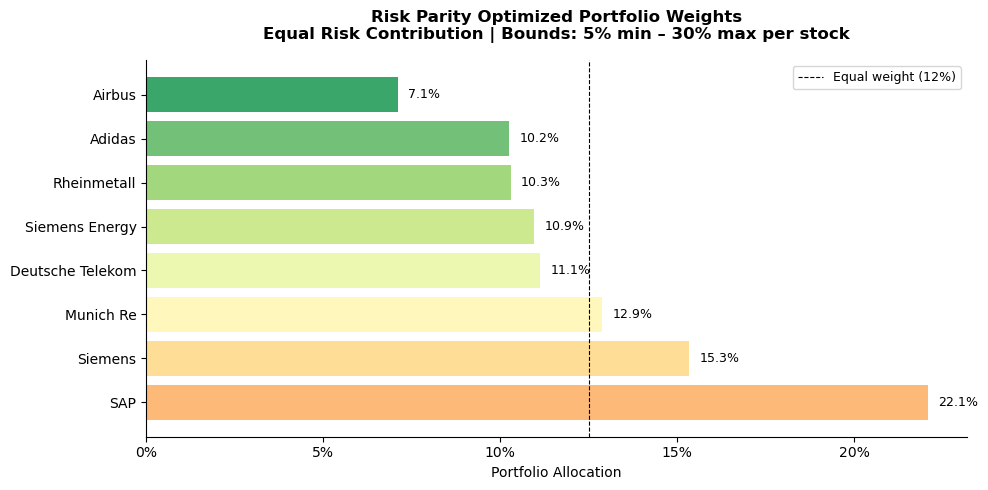

Saved to data/02_portfolio_weights.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(weights_df)))
bars   = ax.barh(
    weights_df['Company'],
    weights_df['Weight'],
    color=colors, alpha=0.85
)

ax.axvline(
    1 / n, color='black', linewidth=0.8,
    linestyle='--', label=f'Equal weight ({1/n:.0%})'
)
ax.set_title(
    'Risk Parity Optimized Portfolio Weights\n'
    'Equal Risk Contribution | Bounds: 5% min – 30% max per stock',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('Portfolio Allocation', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, w in zip(bars, weights_df['Weight']):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'{w:.1%}', va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('data/02_portfolio_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/02_portfolio_weights.png")